In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
import cmcrameri as cm
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import statsmodels.api as sm
import pymannkendall as mk
from global_land_mask import globe

In [3]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/observations_reanalysis_data/'
ref_timeslice=slice(1950,1980)

Arctic_limit = 60
land_longitudes = slice(0,300) # Exclude Greenland

spring_summer_months = [3, 4, 5, 6, 7, 8]
spring_summer_label = 'MAMJJA'
summer_months = [6, 7, 8]

## Extract data and calculate regional averages

In [4]:
filepath = rpath + 'temperature/ERA5_t2m_global.nc'
temp_ERA5 = xr.open_dataset(filepath)
temp_ERA5 = temp_ERA5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
temp_ERA5 = temp_ERA5.reindex(lat=list(reversed(temp_ERA5.lat)))

# Calculate area-weighted regional average
temp_ERA5_global = functions.computeWeightedMean(temp_ERA5)
# Calculate area-weighted regional average
temp_ERA5_Arctic = functions.computeWeightedMean(temp_ERA5.sel(lat=slice(60,90)))

temp_global_annual = temp_ERA5_global.groupby(temp_ERA5_global['time.year']).mean('time')
deltaT_global = temp_global_annual['t2m'] - temp_global_annual['t2m'].sel(year=ref_timeslice).mean('year') 

## Calculate temporal averages and anomalies

In [ ]:
temp_global_annual = temp_ERA5_global.groupby(temp_ERA5_global['time.year']).mean('time')
deltaT_global = temp_global_annual['t2m'] - temp_global_annual['t2m'].sel(year=ref_timeslice).mean('year') 

temp_Arctic_season = temp_ERA5_Arctic.sel(time = temp_ERA5_Arctic['time.month'].isin(summer_months)) # Select June, July and August
temp_Arctic_season = temp_Arctic_season.groupby(temp_Arctic_season['time.year']).mean('time')
deltaT_Arctic_season = temp_Arctic_season['t2m'] - temp_Arctic_season['t2m'].sel(year=ref_timeslice).mean('year')

temp_Arctic_annual = temp_ERA5_Arctic.groupby(temp_ERA5_Arctic['time.year']).mean('time')
deltaT_Arctic_annual = temp_Arctic_annual['t2m'] - temp_Arctic_annual['t2m'].sel(year=ref_timeslice).mean('year')

<>:20: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:20: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_1891488/218643680.py:20: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel('$\Delta$ Surface air temperature $^{\circ}$C')


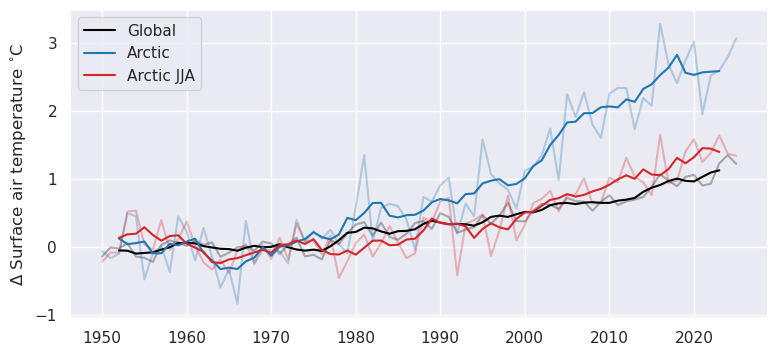

In [ ]:
sns.set_theme()
window = 5

c_global = 'black' 
c_Arctic = 'tab:blue'
c_Arctic_JJA = 'tab:red'

fig = plt.figure(figsize=[9,4])

plt.plot(deltaT_global.year, deltaT_global, c=c_global, alpha=0.3)
plt.plot(deltaT_global.year, deltaT_Arctic_annual, c=c_Arctic, alpha=0.3)
plt.plot(deltaT_global.year, deltaT_Arctic_season, c=c_Arctic_JJA, alpha=0.3)

plt.plot(deltaT_global.year, functions.moving_average(deltaT_global.values, window=window, fillNan=True),c=c_global,  label='Global')
plt.plot(deltaT_global.year, functions.moving_average(deltaT_Arctic_annual.values, window=window, fillNan=True),  c=c_Arctic,label='Arctic')
plt.plot(deltaT_global.year, functions.moving_average(deltaT_Arctic_season.values, window=window, fillNan=True),  c=c_Arctic_JJA, label='Arctic JJA')

plt.ylabel('$\Delta$ Surface air temperature $^{\circ}$C')

plt.legend()

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA10.png',bbox_inches = 'tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA10.pdf',bbox_inches = 'tight')
